# Acquisition d'un dataset de gestes avec la Seeed XIAO nRF52840 Sense

Ce notebook permet de construire un dataset équilibré de **300 gestes** :

| Label | Nombre d'acquisitions |
|---|---:|
| `Wingardium Leviosa` | 100 |
| `Stupefy` | 100 |
| `Expelliarmus` | 100 |

Chaque acquisition dure **5 secondes** et contient les six axes de l'IMU :

- accéléromètre : `AxX`, `AxY`, `AxZ` ;
- gyroscope : `GxX`, `GxY`, `GxZ`.

Les acquisitions sont enregistrées une par une dans le dossier `dataset_sorts_xiao/acquisitions`. Donc une campagne interrompue peut être reprise sans perdre les gestes déjà réalisés.

À la fin, le notebook crée :

- `dataset_sorts_xiao.csv` : dataset global directement importable dans le sujet 3A ;
- `dataset_sorts_xiao.zip` : archive contenant les acquisitions, le CSV global et le descriptif ;
- `descriptif.csv` : résumé d'une ligne par geste.

## 1. Programme Arduino à téléverser sur la carte

1. Installer le support de la **Seeed XIAO nRF52840 Sense** dans l'IDE Arduino.
2. Installer la bibliothèque **Seeed Arduino LSM6DS3**.
3. Téléverser le programme ci-dessous.
4. Fermer le moniteur série de l'IDE Arduino avant de lancer l'acquisition depuis Python.

La carte attend la commande `S`, mesure pendant cinq secondes à environ **50 Hz**, puis envoie `FIN`.

```cpp
// Seeed XIAO nRF52840 Sense — acquisition IMU commandée par le port série
#include <LSM6DS3.h>
#include <Wire.h>

LSM6DS3 imu(I2C_MODE, 0x6A);

const unsigned long DUREE_MS = 5000;
const unsigned long PERIODE_US = 20000; // 20 ms = 50 Hz

void setup() {
  Serial.begin(115200);
  while (!Serial && millis() < 5000) {}

  if (imu.begin() != 0) {
    Serial.println("ERREUR_IMU");
    while (1) { delay(1000); }
  }

  Serial.println("PRET");
}

void loop() {
  if (Serial.available() && Serial.read() == 'S') {
    unsigned long debut = millis();
    unsigned long prochain = micros();

    while (millis() - debut < DUREE_MS) {
      if ((long)(micros() - prochain) >= 0) {
        prochain += PERIODE_US;

        float ax = imu.readFloatAccelX();
        float ay = imu.readFloatAccelY();
        float az = imu.readFloatAccelZ();
        float gx = imu.readFloatGyroX();
        float gy = imu.readFloatGyroY();
        float gz = imu.readFloatGyroZ();

        Serial.print(ax, 6); Serial.print(",");
        Serial.print(ay, 6); Serial.print(",");
        Serial.print(az, 6); Serial.print(",");
        Serial.print(gx, 6); Serial.print(",");
        Serial.print(gy, 6); Serial.print(",");
        Serial.println(gz, 6);
      }
    }

    Serial.println("FIN");
  }
}
```

## 2. Installation et configuration

Adapter `PORT` au port série de la carte.

La cellule affiche aussi les ports détectés pour aider à choisir.

In [4]:
%pip install -q pyserial pandas matplotlib
!pip install pyserial
%pip install pyserial

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:


import json
import re
import shutil
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import serial
from IPython.display import clear_output, display
from serial.tools import list_ports

# --------------------------- Réglages ---------------------------
PORT = "COM10"              # À MODIFIER
BAUDRATE = 115200
DUREE_ACQUISITION = 5       # secondes
NB_GESTES_PAR_LABEL = 100
MIN_ECHANTILLONS = 220      # environ 250 attendus à 50 Hz
MAX_ECHANTILLONS = 280

LABELS = [
    "Wingardium Leviosa",
    "Stupefy",
    "Expelliarmus",
]

COLONNES_CAPTEURS = ["AxX", "AxY", "AxZ", "GxX", "GxY", "GxZ"]
COLONNES_DATASET = COLONNES_CAPTEURS + ["source_file", "label", "origine"]

DOSSIER_DATASET = Path("dataset_sorts_xiao")
DOSSIER_ACQUISITIONS = DOSSIER_DATASET / "acquisitions"
DOSSIER_ACQUISITIONS.mkdir(parents=True, exist_ok=True)

print("Ports série détectés :")
ports = list(list_ports.comports())
if not ports:
    print("  Aucun port détecté.")
else:
    for port in ports:
        print(f"  {port.device:20s} — {port.description}")

print(f"\nDossier de travail : {DOSSIER_DATASET.resolve()}")

Ports série détectés :
  COM10                — Périphérique série USB (COM10)

Dossier de travail : \\netapp2\bassant-koum\Stage IA\Jupyter notebook\dataset_sorts_xiao


## 3. Fonctions d'acquisition et de reprise

Chaque fichier CSV représente un geste complet. Son nom contient le label, son numéro et l'heure d'enregistrement.

Une acquisition est acceptée seulement si elle contient un nombre cohérent d'échantillons. Une acquisition invalide n'est pas comptée parmi les 100 gestes.

In [2]:
def nom_fichier_label(label: str) -> str:
    """Transforme un label en nom de fichier simple."""
    texte = re.sub(r"[^A-Za-z0-9]+", "_", label.strip())
    return texte.strip("_")


def fichiers_du_label(label: str):
    """Retourne les acquisitions existantes d'un label, triées par nom."""
    prefixe = nom_fichier_label(label) + "_"
    return sorted(DOSSIER_ACQUISITIONS.glob(f"{prefixe}*.csv"))


def nombre_acquisitions(label: str) -> int:
    return len(fichiers_du_label(label))


def bilan_acquisitions() -> pd.DataFrame:
    lignes = []
    for label in LABELS:
        n = nombre_acquisitions(label)
        lignes.append({
            "label": label,
            "acquisitions": n,
            "objectif": NB_GESTES_PAR_LABEL,
            "restantes": max(0, NB_GESTES_PAR_LABEL - n),
            "progression_%": round(100 * n / NB_GESTES_PAR_LABEL, 1),
        })
    return pd.DataFrame(lignes)


def ouvrir_carte():
    """Ouvre le port série et laisse le temps à la carte de redémarrer."""
    try:
        ser = serial.Serial(PORT, BAUDRATE, timeout=1)
        time.sleep(2)
        ser.reset_input_buffer()
        ser.reset_output_buffer()
        return ser
    except serial.SerialException as exc:
        raise RuntimeError(
            f"Impossible d'ouvrir {PORT}. Vérifier PORT, le câble et la fermeture "
            "du moniteur série Arduino."
        ) from exc


def lire_un_geste(ser) -> pd.DataFrame:
    """Demande une fenêtre de mesure à la carte et renvoie les six axes."""
    donnees = []
    limite = time.time() + DUREE_ACQUISITION + 5

    ser.reset_input_buffer()
    ser.write(b"S")
    ser.flush()

    while time.time() < limite:
        ligne = ser.readline().decode("utf-8", errors="ignore").strip()

        if not ligne or ligne == "PRET":
            continue
        if ligne == "ERREUR_IMU":
            raise RuntimeError("La carte signale une erreur d'initialisation de l'IMU.")
        if ligne == "FIN":
            break

        morceaux = ligne.split(",")
        if len(morceaux) != len(COLONNES_CAPTEURS):
            continue

        try:
            donnees.append([float(x) for x in morceaux])
        except ValueError:
            continue
    else:
        raise TimeoutError("La carte n'a pas envoyé FIN dans le délai prévu.")

    return pd.DataFrame(donnees, columns=COLONNES_CAPTEURS)


def enregistrer_geste(df: pd.DataFrame, label: str) -> Path:
    """Ajoute les métadonnées et sauvegarde un geste dans un CSV."""
    numero = nombre_acquisitions(label) + 1
    horodatage = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
    identifiant = f"{nom_fichier_label(label)}_{numero:03d}_{horodatage}"

    sortie = df.copy()
    sortie["source_file"] = identifiant
    sortie["label"] = label
    sortie["origine"] = "xiao"
    chemin = DOSSIER_ACQUISITIONS / f"{identifiant}.csv"
    sortie.to_csv(chemin, index=False)
    return chemin


def acquisition_valide(df: pd.DataFrame) -> tuple[bool, str]:
    """Contrôle simple avant sauvegarde."""
    if df.empty:
        return False, "aucun échantillon reçu"
    if not MIN_ECHANTILLONS <= len(df) <= MAX_ECHANTILLONS:
        return False, f"{len(df)} échantillons reçus, attendu entre {MIN_ECHANTILLONS} et {MAX_ECHANTILLONS}"
    if df[COLONNES_CAPTEURS].isna().any().any():
        return False, "présence de valeurs manquantes"
    return True, "OK"


display(bilan_acquisitions())

,label,acquisitions,objectif,restantes,progression_%
0,Wingardium Leviosa,0,100,100,0.0
1,Stupefy,0,100,100,0.0
2,Expelliarmus,0,100,100,0.0


## 4. Tester la communication avant la campagne

Cette cellule réalise une acquisition de test, l'affiche, mais **ne la sauvegarde pas**.

Effectuer un geste de test...
Résultat : OK


,AxX,AxY,AxZ,GxX,GxY,GxZ
0,-0.140056,0.019520,1.181936,108.639999,98.209999,-37.450001
1,-0.261568,0.096624,1.113128,151.270004,120.470001,-50.680000
2,-0.265960,0.224480,1.077016,172.619995,147.210007,-61.320000
3,-0.199104,0.384056,0.976488,182.000000,164.009995,-73.639999
4,-0.391376,0.507032,0.885720,165.339996,94.989998,-34.580002


Nombre d'échantillons : 251


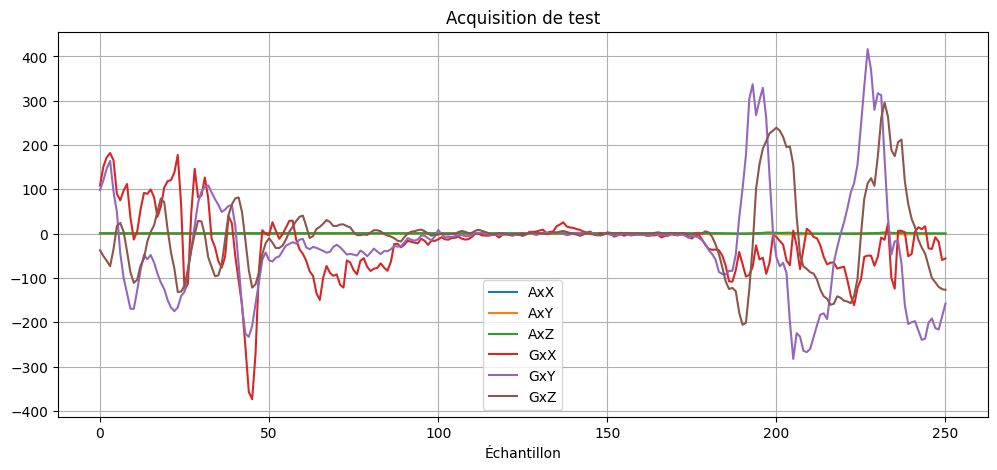

In [3]:
with ouvrir_carte() as ser:
    print("Effectuer un geste de test...")
    test = lire_un_geste(ser)

valide, message = acquisition_valide(test)
print(f"Résultat : {message}")
display(test.head())
print("Nombre d'échantillons :", len(test))

if not test.empty:
    test[COLONNES_CAPTEURS].plot(figsize=(12, 5), title="Acquisition de test")
    plt.xlabel("Échantillon")
    plt.grid(True)
    plt.show()

## 5. Enregistrer une campagne

La fonction suivante :

1. reprend automatiquement au premier numéro manquant ;
2. affiche un compte à rebours avant chaque geste ;
3. enregistre uniquement les acquisitions valides ;
4. demande une validation après chaque acquisition.

Commandes après un geste :

- `Entrée` : conserver le geste ;
- `r` : refaire le geste ;
- `q` : interrompre proprement la campagne.

Pour limiter la fatigue et les gestes dégradés, il est conseillé de travailler par séries de 10 à 20 gestes et de varier légèrement l'orientation initiale.

In [5]:
def enregistrer_campagne(label: str, objectif: int = NB_GESTES_PAR_LABEL, compte_a_rebours: int = 3):
    if label not in LABELS:
        raise ValueError(f"Label inconnu. Choisir parmi : {LABELS}")

    deja_faits = nombre_acquisitions(label)
    if deja_faits >= objectif:
        print(f"{label} possède déjà {deja_faits} acquisitions.")
        return

    print(f"Campagne : {label}")
    print(f"Déjà enregistrés : {deja_faits}/{objectif}")
    print("Entrée = garder, r = refaire, q = arrêter.")

    with ouvrir_carte() as ser:
        while nombre_acquisitions(label) < objectif:
            numero = nombre_acquisitions(label) + 1

            print(f"\n--- {label} : geste {numero}/{objectif} ---")
            input("Placez la carte en position de départ puis appuyez sur Entrée...")

            for seconde in range(compte_a_rebours, 0, -1):
                print(f"Début dans {seconde}...", end="\r")
                time.sleep(1)
            print("GO ! Effectuez le geste pendant 5 secondes.       ")

            try:
                df = lire_un_geste(ser)
            except (TimeoutError, RuntimeError) as exc:
                print("Acquisition échouée :", exc)
                choix = input("Entrée pour réessayer, q pour arrêter : ").strip().lower()
                if choix == "q":
                    break
                continue

            valide, message = acquisition_valide(df)
            print(f"{len(df)} échantillons — contrôle : {message}")

            if not valide:
                print("Le geste n'est pas sauvegardé. Il va être refait.")
                continue

            choix = input("Garder ce geste ? [Entrée=oui / r=refaire / q=arrêter] : ").strip().lower()
            if choix == "q":
                print("Campagne interrompue sans perdre les gestes précédents.")
                break
            if choix == "r":
                print("Geste rejeté.")
                continue

            chemin = enregistrer_geste(df, label)
            print(f"Sauvegardé : {chemin.name}")

    display(bilan_acquisitions())

### Lancer les acquisitions

Exécuter une ligne à la fois. Relancer la même ligne reprend automatiquement la campagne jusqu'à 100 gestes.

In [6]:
# Décommenter UNE ligne à la fois :

enregistrer_campagne("Wingardium Leviosa")
# enregistrer_campagne("Stupefy")
# enregistrer_campagne("Expelliarmus")

Campagne : Wingardium Leviosa
Déjà enregistrés : 0/100
Entrée = garder, r = refaire, q = arrêter.

--- Wingardium Leviosa : geste 1/100 ---


Placez la carte en position de départ puis appuyez sur Entrée... 


GO ! Effectuez le geste pendant 5 secondes.       
251 échantillons — contrôle : OK


Garder ce geste ? [Entrée=oui / r=refaire / q=arrêter] :  q


Campagne interrompue sans perdre les gestes précédents.


,label,acquisitions,objectif,restantes,progression_%
0,Wingardium Leviosa,0,100,100,0.0
1,Stupefy,0,100,100,0.0
2,Expelliarmus,0,100,100,0.0


## 6. Examiner, supprimer ou refaire la dernière acquisition

Cette cellule est utile lorsqu'un geste a été sauvegardé par erreur.

In [7]:
def charger_acquisition(chemin: Path) -> pd.DataFrame:
    return pd.read_csv(chemin)


def afficher_derniere_acquisition(label: str):
    fichiers = fichiers_du_label(label)
    if not fichiers:
        print("Aucune acquisition pour ce label.")
        return

    chemin = fichiers[-1]
    df = charger_acquisition(chemin)
    print("Fichier :", chemin.name)
    print("Échantillons :", len(df))
    display(df.head())

    df[COLONNES_CAPTEURS].plot(figsize=(12, 5), title=f"Dernière acquisition — {label}")
    plt.xlabel("Échantillon")
    plt.grid(True)
    plt.show()


def supprimer_derniere_acquisition(label: str):
    fichiers = fichiers_du_label(label)
    if not fichiers:
        print("Aucune acquisition à supprimer.")
        return

    chemin = fichiers[-1]
    confirmation = input(f"Supprimer définitivement {chemin.name} ? [oui/N] : ").strip().lower()
    if confirmation == "oui":
        chemin.unlink()
        print("Acquisition supprimée.")
    else:
        print("Suppression annulée.")


# Exemples :
# afficher_derniere_acquisition("Stupefy")
# supprimer_derniere_acquisition("Stupefy")

## 7. Construire et contrôler le dataset global

Le dataset final respecte le format utilisé dans `sujet_3A` :

`AxX, AxY, AxZ, GxX, GxY, GxZ, source_file, label, origine`

In [8]:
def construire_dataset_global() -> pd.DataFrame:
    fichiers = sorted(DOSSIER_ACQUISITIONS.glob("*.csv"))
    if not fichiers:
        raise RuntimeError("Aucune acquisition n'a encore été enregistrée.")

    morceaux = []
    for chemin in fichiers:
        df = pd.read_csv(chemin)
        colonnes_manquantes = set(COLONNES_DATASET) - set(df.columns)
        if colonnes_manquantes:
            raise ValueError(f"{chemin.name} : colonnes manquantes {colonnes_manquantes}")
        morceaux.append(df[COLONNES_DATASET])

    return pd.concat(morceaux, ignore_index=True)


data = construire_dataset_global()

resume = (
    data.groupby("label")
    .agg(
        acquisitions=("source_file", "nunique"),
        echantillons=("source_file", "size"),
    )
    .reindex(LABELS)
)

tailles = data.groupby(["label", "source_file"]).size()
resume["min_echantillons_par_geste"] = tailles.groupby(level=0).min()
resume["max_echantillons_par_geste"] = tailles.groupby(level=0).max()
resume["moyenne_echantillons_par_geste"] = tailles.groupby(level=0).mean().round(1)

display(resume)
print("Shape du dataset :", data.shape)
print("Valeurs manquantes :", int(data.isna().sum().sum()))
print("Acquisitions dupliquées :", int(data[["source_file"]].drop_duplicates().duplicated().sum()))

data.head()

RuntimeError: Aucune acquisition n'a encore été enregistrée.

## 8. Export pour le sujet 3A

L'export est autorisé uniquement lorsque chaque label possède exactement 100 acquisitions.

L'archive ZIP conserve également les fichiers individuels, ce qui permet de corriger ou d'auditer le dataset ultérieurement.

In [9]:
def exporter_dataset():
    data = construire_dataset_global()
    compte = data.groupby("label")["source_file"].nunique().reindex(LABELS, fill_value=0)

    erreurs = {
        label: int(nombre)
        for label, nombre in compte.items()
        if nombre != NB_GESTES_PAR_LABEL
    }
    if erreurs:
        raise RuntimeError(
            "Export bloqué : il faut exactement "
            f"{NB_GESTES_PAR_LABEL} acquisitions par label. État actuel : {erreurs}"
        )

    csv_global = Path("dataset_sorts_xiao.csv")
    manifeste = DOSSIER_DATASET / "manifest.csv"
    metadata = DOSSIER_DATASET / "metadata.json"

    data.to_csv(csv_global, index=False)

    manifest_df = (
        data.groupby(["source_file", "label", "origine"], as_index=False)
        .agg(nombre_echantillons=("AxX", "size"))
    )
    manifest_df.to_csv(manifeste, index=False)

    metadata.write_text(
        json.dumps(
            {
                "date_export": datetime.now().isoformat(timespec="seconds"),
                "labels": LABELS,
                "acquisitions_par_label": NB_GESTES_PAR_LABEL,
                "duree_acquisition_s": DUREE_ACQUISITION,
                "colonnes": COLONNES_DATASET,
                "nombre_total_acquisitions": int(data["source_file"].nunique()),
                "nombre_total_lignes": int(len(data)),
            },
            ensure_ascii=False,
            indent=2,
        ),
        encoding="utf-8",
    )

    # Une copie du CSV global est placée dans le dossier avant création du ZIP.
    shutil.copy2(csv_global, DOSSIER_DATASET / csv_global.name)
    archive = shutil.make_archive("dataset_sorts_xiao", "zip", root_dir=DOSSIER_DATASET)

    print("Export terminé :")
    print(" -", csv_global.resolve())
    print(" -", Path(archive).resolve())
    print(" -", manifeste.resolve())
    return csv_global, Path(archive)


# À exécuter lorsque le bilan indique 100 acquisitions pour chaque label :
# csv_global, archive_zip = exporter_dataset()

## 9. Importer l'export dans `sujet_3A`

Placer `dataset_sorts_xiao.csv` dans le même dossier que le notebook `sujet_3A`, puis remplacer la cellule d'importation de l'ancien ZIP par la cellule suivante.

Le reste du sujet peut continuer à utiliser la variable `data` sans modification.

In [10]:
import pandas as pd

data = pd.read_csv("dataset_sorts_xiao.csv")

colonnes_attendues = [
    "AxX", "AxY", "AxZ",
    "GxX", "GxY", "GxZ",
    "source_file", "label", "origine",
]

colonnes_manquantes = set(colonnes_attendues) - set(data.columns)
if colonnes_manquantes:
    raise ValueError(f"Colonnes manquantes : {colonnes_manquantes}")

print("Taille du dataset :", data.shape)
display(
    data.groupby("label")["source_file"]
    .nunique()
    .rename("nombre_de_gestes")
    .to_frame()
)
data.head()

FileNotFoundError: [Errno 2] No such file or directory: 'dataset_sorts_xiao.csv'

## Conseils pour obtenir un dataset exploitable

- Utiliser toujours la même main et la même manière de tenir la carte.
- Conserver une durée de cinq secondes pour chaque acquisition.
- Commencer le geste après le signal `GO`.
- Enregistrer les gestes dans plusieurs séances plutôt que 100 répétitions sans pause.
- Faire varier raisonnablement la vitesse, l'amplitude et la position initiale.
- Éviter qu'un label soit enregistré dans des conditions totalement différentes des autres.
- Contrôler régulièrement les courbes et refaire les acquisitions manifestement incorrectes.
- Ne pas interrompre le kernel pendant qu'une acquisition série est en cours.